# Valuation, Risk & Technical Analysis

## Introduction

This notebook extends the financial analysis by examining the company's valuation, relative valuation, market risk and technical indicators.

The analysis combines fundamental valuation measures with historical market data to provide a broader view of the company.

### Analysis Areas

The notebook covers three principal areas:

- **Valuation Analysis** – examines enterprise-value-based valuation multiples and compares the company with selected peers.
- **Risk Analysis** – evaluates historical returns and annualised volatility.
- **Technical Analysis** – examines price-based indicators including moving averages, RSI and MACD.

The final section combines the outputs from the analysis into an automated investment report.

## Valuation Analysis

This section evaluates the company's valuation using enterprise-value-based multiples.

Enterprise value is compared with revenue and EBITDA to provide an indication of how the market is valuing the company relative to its underlying financial performance.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
income_statement = pd.read_csv(
    "income_statement.csv",
    index_col=0
)

balance_sheet = pd.read_csv(
    "balance_sheet.csv",
    index_col=0
)

cash_flow = pd.read_csv(
    "cash_flow.csv",
    index_col=0
)

history = pd.read_csv(
    "history.csv",
    index_col=0
)

### Ticker

In [22]:
import yfinance as yf
ticker = input("Enter ticker: ").upper()

company = yf.Ticker(ticker)

Enter ticker:  MSFT


### Company Information

In [23]:
info = company.info

valuation = pd.DataFrame({

    "Market Cap ($bn)": [
        info.get("marketCap", np.nan) / 1e9
    ],

    "Enterprise Value ($bn)": [
        info.get("enterpriseValue", np.nan) / 1e9
    ],

    "Trailing P/E": [
        info.get("trailingPE", np.nan)
    ],

    "Forward P/E": [
        info.get("forwardPE", np.nan)
    ],

    "PEG Ratio": [
        info.get("pegRatio", np.nan)
    ],

    "Price/Book": [
        info.get("priceToBook", np.nan)
    ]

})

valuation

,Market Cap ($bn),Enterprise Value ($bn),Trailing P/E,Forward P/E,PEG Ratio,Price/Book
0,3792.152035,3884.81391,28.434856,21.570053,1.68,8.573659


### Enterprise Value / Revenue

The EV/Revenue multiple compares the company's enterprise value with the revenue it generates.

This provides a valuation measure that can be used to compare companies with different capital structures.

In [43]:
enterprise_value = info.get("enterpriseValue")

latest_revenue = income_statement["Total Revenue"].iloc[0]

ev_revenue = enterprise_value / latest_revenue

print(f"EV/Revenue: {ev_revenue:.2f}x")

EV/Revenue: 11.71x


### Enterprise Value / EBITDA

The EV/EBITDA multiple compares enterprise value with EBITDA and is commonly used to assess valuation relative to operating earnings before interest, tax, depreciation and amortisation.

In [25]:
ebitda = info.get("ebitda")

ev_ebitda = enterprise_value / ebitda

ev_ebitda

20.00037991491728

### Valuation Interpretation

In [26]:
valuation["EV/Revenue"] = ev_revenue

valuation["EV/EBITDA"] = ev_ebitda

valuation

,Market Cap ($bn),Enterprise Value ($bn),Trailing P/E,Forward P/E,PEG Ratio,Price/Book,EV/Revenue,EV/EBITDA
0,3792.152035,3884.81391,28.434856,21.570053,1.68,8.573659,17.990413,20.00038


## Peer Value Comparison

This section compares the company's valuation multiples with those of selected peer companies.

Comparing valuation multiples across companies within the same or a similar industry provides additional context for interpreting the company's valuation.

In [27]:
peers = [
    ticker,
    "AMD",
    "AVGO",
    "INTC"
]

### Peer Comparison Table

In [28]:
def get_valuation_metrics(ticker):

    company = yf.Ticker(ticker)
    info = company.info

    return {
        "Company": ticker,
        "Market Cap ($bn)": info.get("marketCap", np.nan) / 1e9,
        "P/E": info.get("trailingPE", np.nan),
        "Forward P/E": info.get("forwardPE", np.nan),
        "EV/Revenue": (
            info.get("enterpriseValue", np.nan) /
            info.get("totalRevenue", np.nan)
        ),
        "EV/EBITDA": (
            info.get("enterpriseValue", np.nan) /
            info.get("ebitda", np.nan)
        )
    }

peer_analysis = pd.DataFrame(
    [
        get_valuation_metrics(company)
        for company in peers
    ]
)

peer_analysis

,Company,Market Cap ($bn),P/E,Forward P/E,EV/Revenue,EV/EBITDA
0,MSFT,3792.152035,28.434856,21.570053,11.706923,20.000380
1,AMD,986.218955,154.507680,38.779930,24.710149,106.740505
2,AVGO,1673.777906,44.780334,18.088715,19.299115,32.905250
3,INTC,609.038565,NaN,55.873196,11.516746,39.003744


### Peer Valuation Comparison

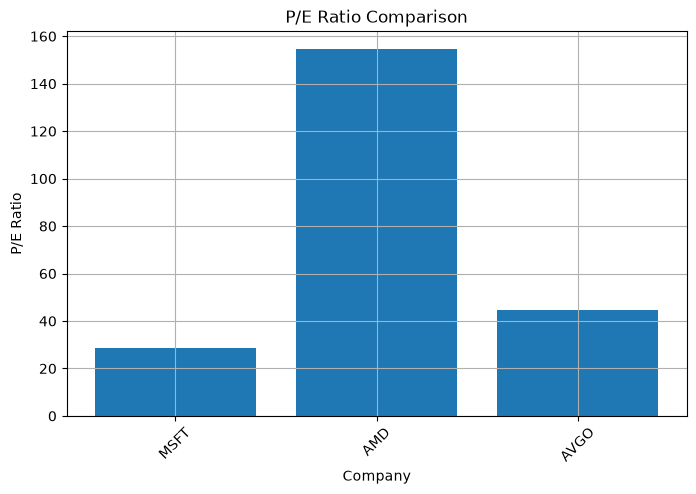

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    peer_analysis["Company"],
    peer_analysis["P/E"]
)

plt.title("P/E Ratio Comparison")

plt.xlabel("Company")

plt.ylabel("P/E Ratio")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Risk Analysis

This section examines historical market risk using the company's historical returns and annualised volatility.

Historical volatility provides an indication of the extent to which the company's share price has fluctuated over the selected period.

### Historical Returns

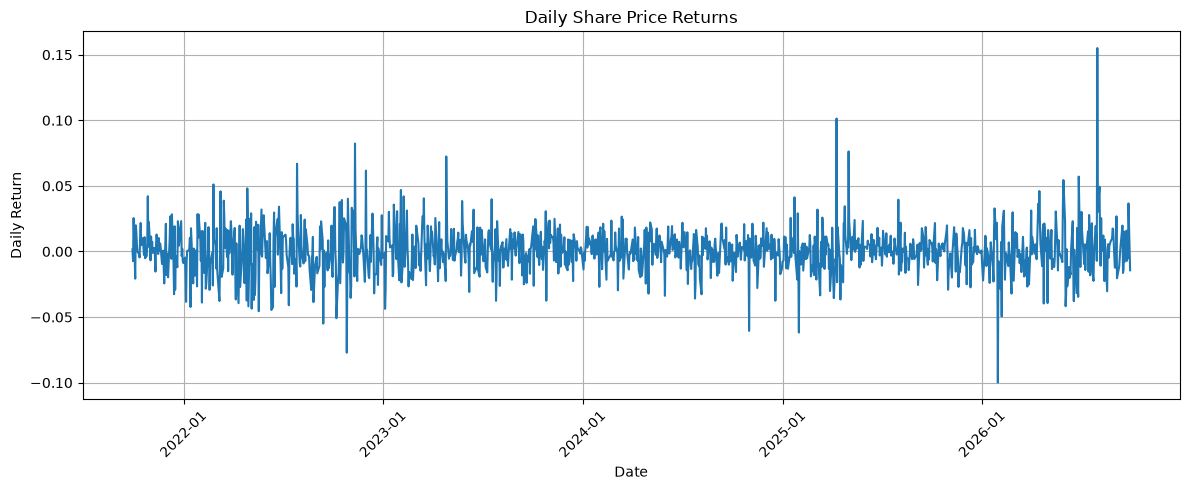

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

history.index = pd.to_datetime(history.index, utc=True)

daily_returns = history["Close"].pct_change().dropna()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_returns.index,
    daily_returns
)

plt.title("Daily Share Price Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

### Annualised Volatility

In [48]:
annual_volatility = daily_returns.std() * np.sqrt(252)

annual_volatility_percentage = annual_volatility * 100

print(f"Annualised Volatility: {annual_volatility_percentage:.2f}%")

Annualised Volatility: 28.21%


## Technical Analysis

This section examines selected technical indicators derived from historical share price data.

The indicators are used to identify historical price trends and momentum characteristics.

### 50-Day vs. 200-Day Moving Average

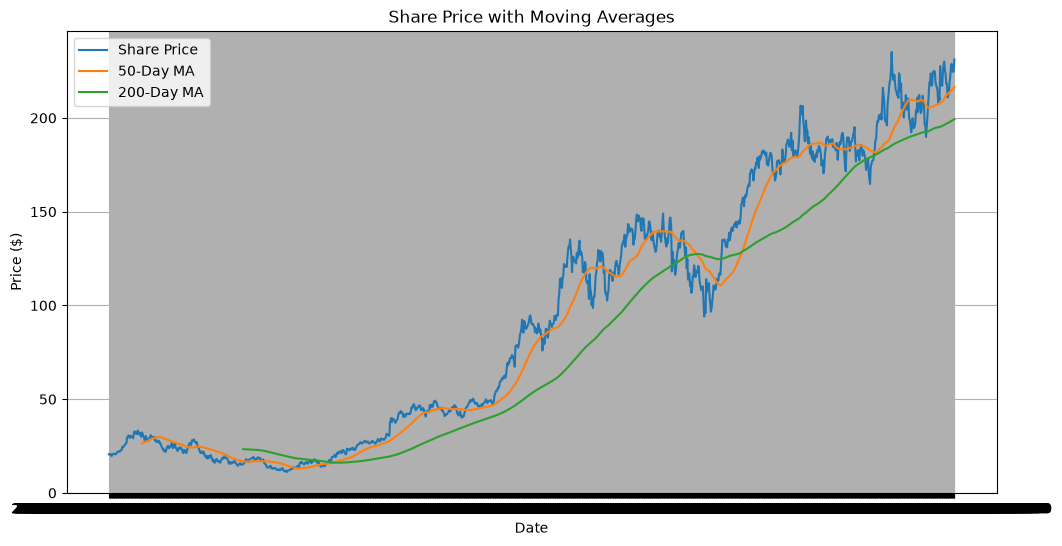

In [32]:
history["MA50"] = history["Close"].rolling(window=50).mean()

history["MA200"] = history["Close"].rolling(window=200).mean()

plt.figure(figsize=(12,6))

plt.plot(history.index, history["Close"], label="Share Price")
plt.plot(history.index, history["MA50"], label="50-Day MA")
plt.plot(history.index, history["MA200"], label="200-Day MA")

plt.title("Share Price with Moving Averages")

plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()

plt.grid(True)

plt.show()

### Relative Strength Index (RSI)

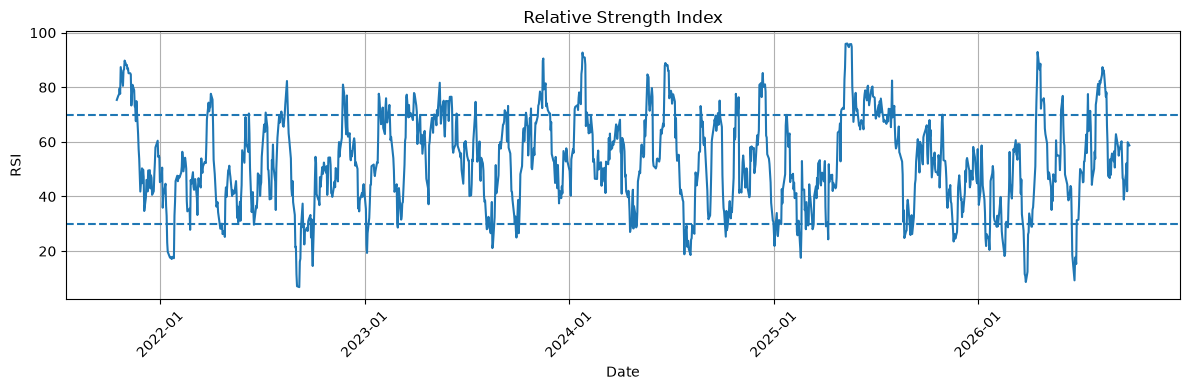

In [52]:
history.index = pd.to_datetime(history.index, utc=True)

delta = history["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

average_gain = gain.rolling(14).mean()
average_loss = loss.rolling(14).mean()

rs = average_gain / average_loss

history["RSI"] = 100 - (100 / (1 + rs))

plt.figure(figsize=(12, 4))

plt.plot(
    history.index,
    history["RSI"]
)

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("Relative Strength Index")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

### Moving Average Convergence Divergence (MACD)

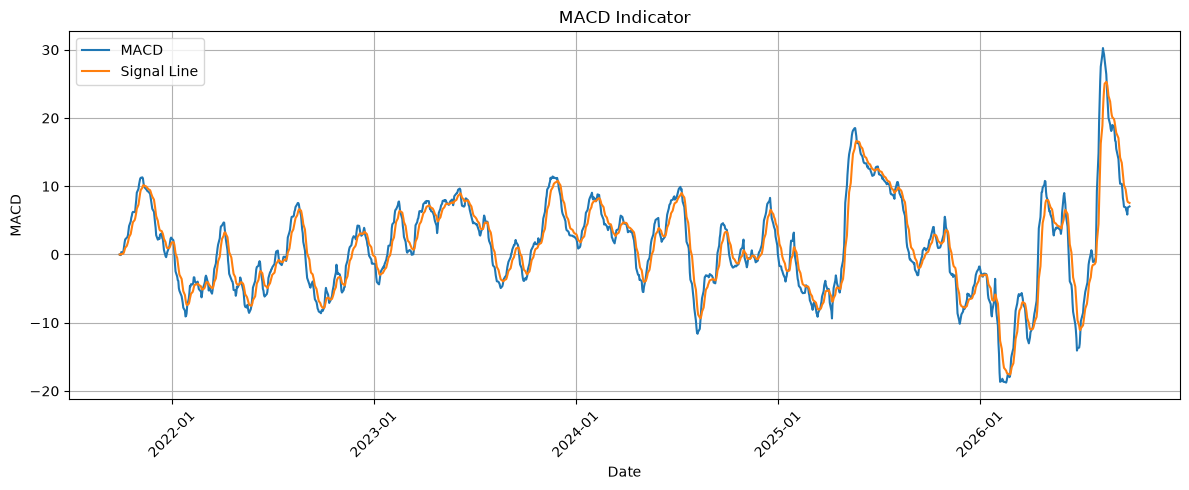

In [53]:
history.index = pd.to_datetime(history.index, utc=True)

history["EMA12"] = history["Close"].ewm(
    span=12,
    adjust=False
).mean()

history["EMA26"] = history["Close"].ewm(
    span=26,
    adjust=False
).mean()

history["MACD"] = history["EMA12"] - history["EMA26"]

history["Signal"] = history["MACD"].ewm(
    span=9,
    adjust=False
).mean()

plt.figure(figsize=(12, 5))

plt.plot(
    history.index,
    history["MACD"],
    label="MACD"
)

plt.plot(
    history.index,
    history["Signal"],
    label="Signal Line"
)

plt.title("MACD Indicator")

plt.xlabel("Date")
plt.ylabel("MACD")

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)
plt.tight_layout()

plt.show()

## Automated Investment Report

This section consolidates the results generated throughout the analysis into a structured automated report.

The report considers the company's financial health, valuation and historical market risk using the metrics calculated above.

### Investment Report Input

The investment report uses the outputs generated throughout the preceding analysis to produce a consolidated assessment of the company.

In [35]:

report = {
    "Company": company.info.get("longName", ticker),
    "Sector": company.info.get("sector", "N/A"),
    "Current Price": company.info.get("currentPrice", "N/A"),
    "Market Cap": company.info.get("marketCap", "N/A"),
    "Annual Volatility (%)": annual_volatility_percentage
}

pd.DataFrame(report, index=[0])

,Company,Sector,Current Price,Market Cap,Annual Volatility (%)
0,Microsoft Corporation,Technology,510.715,3792152035328,51.977245


### Financial Health Assessment

This assessment summarises the company's financial performance, profitability, balance sheet position and cash flow characteristics.

In [36]:
financial_score = 0

# Revenue size
if latest_revenue > 0:
    financial_score += 1

# EBITDA profitability
if ebitda > 0:
    financial_score += 1

# Cash flow availability
if "Free Cash Flow" in cash_flow.index:
    latest_fcf = cash_flow.loc["Free Cash Flow"].iloc[0]
    if latest_fcf > 0:
        financial_score += 1


if financial_score == 3:
    financial_view = "Strong"

elif financial_score == 2:
    financial_view = "Moderate"

else:
    financial_view = "Weak"


financial_view

'Moderate'

### Valuation Assessment

This assessment summarises the company's valuation metrics and its valuation relative to the selected peer group.

In [37]:
if ev_ebitda < 15:
    valuation_view = "Potentially Attractive"

elif ev_ebitda < 25:
    valuation_view = "Fairly Valued"

else:
    valuation_view = "Premium Valuation"


print("EV/EBITDA:", round(ev_ebitda, 2))
print("EV/Revenue:", round(ev_revenue, 2))
print("Valuation Assessment:", valuation_view)

EV/EBITDA: 20.0
EV/Revenue: 17.99
Valuation Assessment: Fairly Valued


### Risk Assessment

This assessment summarises the company's historical return characteristics, annualised volatility and relevant market indicators.

In [38]:
if annual_volatility_percentage < 20:
    risk_view = "Low"

elif annual_volatility_percentage < 40:
    risk_view = "Moderate"

else:
    risk_view = "High"


print("Annual Volatility:", round(annual_volatility_percentage, 2), "%")
print("Risk Assessment:", risk_view)

Annual Volatility: 51.98 %
Risk Assessment: High


### Investment Report Summary

The final summary brings together the financial health, valuation and risk assessments into a single automated report.

In [56]:
print("=" * 65)
print("              EQUITY RESEARCH SUMMARY")
print("=" * 65)

print(f"\nCompany: {report['Company']}")
print(f"Sector: {report['Sector']}")

print("\n--------------------------------")
print("Financial Assessment")
print("--------------------------------")
print(financial_view)

print("\n--------------------------------")
print("Valuation Assessment")
print("--------------------------------")
print(valuation_view)

print("\n--------------------------------")
print("Risk Assessment")
print("--------------------------------")
print(risk_view)

print("\n--------------------------------")
print("Key Metrics")
print("--------------------------------")

print(f"Revenue: {latest_revenue / 1e9:.2f}bn")
print(f"EV/Revenue: {ev_revenue:.2f}x")
print(f"EV/EBITDA: {ev_ebitda:.2f}x")
print(f"Annual Volatility: {annual_volatility_percentage:.2f}%")

print("\n--------------------------------")
print("Investment View")
print("--------------------------------")

if financial_view == "Strong" and valuation_view != "Premium Valuation":

    investment_view = (
        "Positive outlook based on strong financial performance "
        "and reasonable valuation."
    )

elif financial_view == "Strong" and valuation_view == "Premium Valuation":

    investment_view = (
        "Strong business fundamentals, although the valuation "
        "reflects high market expectations."
    )

elif financial_view == "Weak":

    investment_view = (
        "Caution warranted due to weaker financial indicators."
    )

else:

    investment_view = (
        "Mixed outlook based on the current financial, valuation "
        "and risk indicators."
    )

print(investment_view)

print("\n" + "=" * 65)

              EQUITY RESEARCH SUMMARY

Company: Microsoft Corporation
Sector: Technology

--------------------------------
Financial Assessment
--------------------------------
Moderate

--------------------------------
Valuation Assessment
--------------------------------
Fairly Valued

--------------------------------
Risk Assessment
--------------------------------
High

--------------------------------
Key Metrics
--------------------------------
Revenue: 331.84bn
EV/Revenue: 11.71x
EV/EBITDA: 20.00x
Annual Volatility: 28.21%

--------------------------------
Investment View
--------------------------------
Mixed outlook based on the current financial, valuation and risk indicators.

